# ₿ Bitcoin Price Forecasting & Market Analysis (2014–2026)
### Prediction Notebook — SARIMAX & Monte Carlo Simulation


## Project Description
This notebook forecasts Bitcoin's monthly closing price through **December 2026** using two complementary methods: a **SARIMAX** time series model and a **Monte Carlo simulation** built on bootstrapped historical monthly returns. The analysis uses a daily OHLCV dataset (`bitcoin_dataset.csv`) covering **September 17, 2014 to June 5, 2026 (4,280 trading days)**.


## Overview
The notebook follows a six-stage pipeline: import and clean the daily data → resample to monthly closes → fit a SARIMAX model → run a 10,000-path Monte Carlo simulation → combine both forecasts into a single chart → summarize the December 2026 outlook in a forecast table.


## Introduction
Bitcoin is one of the most volatile assets tracked in financial markets, moving from under $500 in 2014 to over $60,000 by mid-2026, through repeated multi-year rallies and corrections. Because a single deterministic forecast can be misleading for an asset this volatile, this project deliberately pairs a trend-based statistical model (SARIMAX) with a simulation-based probabilistic model (Monte Carlo), so that any price projection is expressed as a **range**, not a single number.


## Problem Statement
Given Bitcoin's historically extreme volatility, how can we produce a defensible, business-usable price forecast through December 2026 that reflects both the expected trend **and** the genuine uncertainty around it — rather than a single, overconfident number?


## Methodology
1. **Data Preparation** — import, parse, and index the daily OHLCV dataset.
2. **Exploratory Analysis** — visualize the full daily closing price series.
3. **Monthly Transformation** — resample to month-end closes; engineer log close and log return features.
4. **SARIMAX Forecasting** — fit SARIMAX(1,1,1) on monthly log-close, forecasting 6 months ahead to Dec 2026 with an 80% confidence interval.
5. **Monte Carlo Simulation** — bootstrap 10,000 paths from historical monthly returns to build a P10 / P50 / P90 probability range.
6. **Forecast Comparison** — overlay both methods against recent actuals and summarize the December 2026 outlook.


### 1. Data Preparation


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
df= pd.read_csv(r'C:\Users\user\Desktop\DATA ANALYSIS      140426\project\bitcoin_dataset.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [14]:
#df = df.sort_values('Date').set_index('Date')
print(f"Data range:{df.index.min().date()} to {df.index.max().date()}")
print(f"Trading days :{len(df)}")

Data range:2014-09-17 to 2026-06-05
Trading days :4280


**Insight:** The dataset spans **4,280 daily trading observations**, from **September 17, 2014** to **June 5, 2026** — just under twelve years of continuous Bitcoin price history.


### 2. Exploratory Analysis — Daily Closing Price


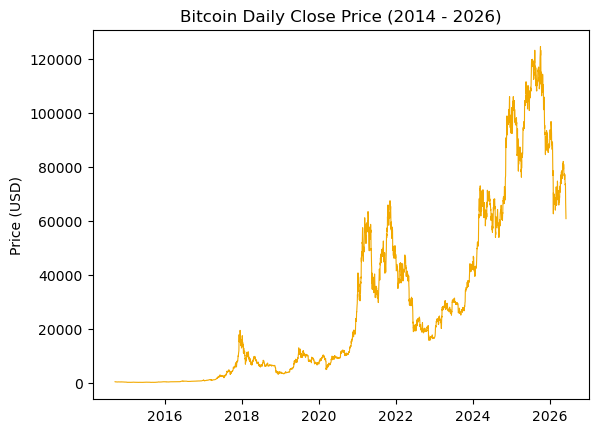

In [19]:
fig, ax = plt.subplots()
ax.plot(df.index, df['Close'], linewidth=0.8, color='#f2a900')
ax.set_title('Bitcoin Daily Close Price (2014 - 2026)')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.show()

**Insight:** The daily close chart shows Bitcoin's historically non-linear growth path, marked by multi-year rallies followed by sharp corrections. Based on this same dataset, Bitcoin reached an **all-time high of $124,753 (October 6, 2025)** and an **all-time low of $178 (January 14, 2015)**, for a cumulative return of roughly **+13,221%** and a **maximum drawdown of approximately –83%** from peak to trough.


## 2. Resample to monthly close

Daily data is noisy for a multi-month forecast horizon, so we work with
month-end closing prices. Note: the last month (June 2026) is incomplete —
only 5 trading days are available — so it is treated as a partial data point,
not a finished month.

In [21]:
monthly = df['Close'].resample('ME').last().to_frame('Close')
monthly['LogClose'] = np.log(monthly['Close'])
monthly['LogReturn'] = monthly['LogClose'].diff()

last_actual_date = df.index.max()
last_actual_price = df['Close'].iloc[-1]

print(f"Last available price: ${last_actual_price:,.2f} on {last_actual_date.date()}")
print(f"Months of monthly data: {len(monthly)}")
monthly.head(8)

Last available price: $60,922.67 on 2026-06-05
Months of monthly data: 142


,Close,LogClose,LogReturn
Date,,,
2014-09-30,386.944000,5.958280,NaN
2014-10-31,338.321014,5.823995,-0.134285
2014-11-30,378.046997,5.935019,0.111023
2014-12-31,320.192993,5.768924,-0.166095
2015-01-31,217.464005,5.382033,-0.386891
2015-02-28,254.263000,5.538369,0.156336
2015-03-31,244.223999,5.498086,-0.040283
2015-04-30,236.145004,5.464446,-0.033640


**Insight:** Resampling produces **142 monthly observations**. The most recent available close is **$60,922.67 (June 5, 2026)**; this final month is incomplete and is treated as a partial data point rather than a completed month.


In [22]:
mean_monthly_return = monthly['LogReturn'].mean()
std_monthly_return = monthly['LogReturn'].std()

print(f"Historical average monthly log-return: {mean_monthly_return:.4f} ({(np.exp(mean_monthly_return)-1)*100:.2f}% simple)")
print(f"Historical monthly return volatility (std dev): {std_monthly_return:.4f}")

Historical average monthly log-return: 0.0359 (3.65% simple)
Historical monthly return volatility (std dev): 0.1936


**Insight:** Bitcoin's historical **average monthly return is +3.65%**, but with a **standard deviation of 19.36% per month** — over five times the average. This confirms that individual monthly outcomes vary enormously around the long-run trend, which is why both a confidence interval (SARIMAX) and a full simulated distribution (Monte Carlo) are used below rather than a single expected value.


### 3. SARIMAX Forecasting
A SARIMAX(1,1,1) model is fit on the monthly log-close series to project Bitcoin's price six months ahead, through December 2026, along with an 80% confidence interval.


In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

log_series = monthly['LogClose']

# Horizon: number of months from the last data point to Dec 2026 inclusive
target_end = pd.Timestamp('2026-12-31')
horizon = (target_end.year - log_series.index[-1].year) * 12 + (target_end.month - log_series.index[-1].month)
print(f"Forecasting {horizon} months ahead, through {target_end.date()}")

model = SARIMAX(log_series, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)

forecast = fit.get_forecast(steps=horizon)
forecast_index = pd.date_range(log_series.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq='ME')

pred_log = forecast.predicted_mean
ci_log = forecast.conf_int(alpha=0.20)  # 80% interval

sarimax_df = pd.DataFrame({
    'Forecast': np.exp(pred_log.values),
    'Lower_80': np.exp(ci_log.iloc[:, 0].values),
    'Upper_80': np.exp(ci_log.iloc[:, 1].values)
}, index=forecast_index)

sarimax_df

Forecasting 6 months ahead, through 2026-12-31


,Forecast,Lower_80,Upper_80
2026-07-31,59228.286126,46288.475607,75785.383541
2026-08-31,57940.150684,39919.169516,84096.465481
2026-09-30,56955.422005,35192.404520,92176.710855
2026-10-31,56199.379892,31440.533071,100455.367379
2026-11-30,55616.959812,28367.823829,109040.659494
2026-12-31,55167.112150,25800.639496,117958.714295


**Insight:** The model's point forecast trends gently downward across the horizon, from **$59,228 (Jul 2026)** to **$55,167 (Dec 2026)**, while its 80% confidence interval widens sharply — from **$46,288–$75,785** in July to **$25,801–$117,959** by December. This reflects SARIMAX's tendency to extrapolate the recent (declining) trend while acknowledging growing uncertainty further out.


## 4. Monte Carlo simulation (bootstrapped historical returns)

Rather than assuming one statistical model is "correct," this simulates thousands
of possible future paths by randomly resampling actual historical monthly returns
(including the wild ones — the 2017, 2021, and 2024 rallies as well as the
2018, 2022 and recent drawdowns). This produces a realistic range of outcomes.

In [24]:
np.random.seed(42)

n_sims = 10000
historical_returns = monthly['LogReturn'].dropna().values

sim_paths = np.zeros((n_sims, horizon))
for i in range(n_sims):
    sampled_returns = np.random.choice(historical_returns, size=horizon, replace=True)
    sim_paths[i] = last_actual_price * np.exp(np.cumsum(sampled_returns))

mc_p10 = np.percentile(sim_paths, 10, axis=0)
mc_p50 = np.percentile(sim_paths, 50, axis=0)
mc_p90 = np.percentile(sim_paths, 90, axis=0)

mc_df = pd.DataFrame({
    'P10_Bear': mc_p10,
    'P50_Median': mc_p50,
    'P90_Bull': mc_p90
}, index=forecast_index)

mc_df

,P10_Bear,P50_Median,P90_Bull
2026-07-31,50442.881705,62613.366826,81080.361754
2026-08-31,46856.493266,65135.692463,93181.832748
2026-09-30,44545.150019,67641.886033,103913.914820
2026-10-31,43221.366652,69788.438176,116025.810278
2026-11-30,41726.712588,72877.819812,127976.998626
2026-12-31,40730.034847,75195.960988,139297.347557


**Insight:** Across 10,000 simulated paths, the **median (P50) forecast rises from $62,613 (Jul 2026) to $75,196 (Dec 2026)** — notably higher than SARIMAX's point forecast — while the 10th–90th percentile range widens from **$50,443–$81,080** to **$40,730–$139,297**. Because the bootstrap resamples real historical monthly returns (including the extreme 2017/2021/2024 rallies and the 2018/2022 crashes), it produces a wider and more upward-skewed range than the statistical model.


## 5. Combined chart

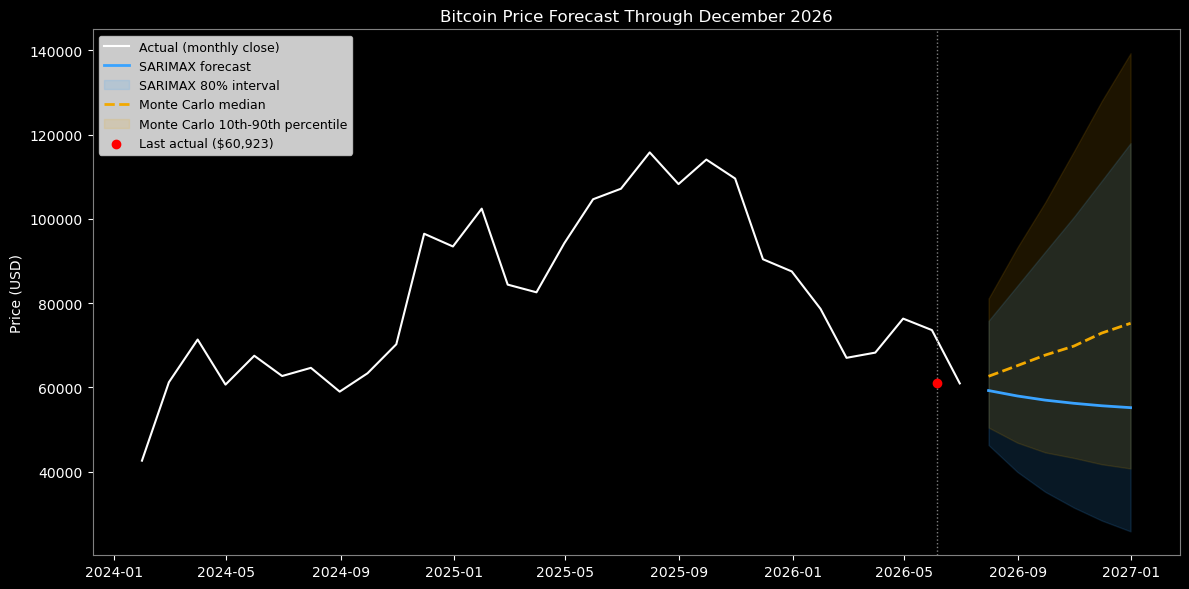

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

# Recent history for context
recent = monthly['Close'].loc['2024-01-01':]
ax.plot(recent.index, recent.values, color='white', linewidth=1.5, label='Actual (monthly close)')

# SARIMAX
ax.plot(sarimax_df.index, sarimax_df['Forecast'], color='#3aa3ff', linewidth=2, label='SARIMAX forecast')
ax.fill_between(sarimax_df.index, sarimax_df['Lower_80'], sarimax_df['Upper_80'],
                color='#3aa3ff', alpha=0.15, label='SARIMAX 80% interval')

# Monte Carlo
ax.plot(mc_df.index, mc_df['P50_Median'], color='#f2a900', linewidth=2, linestyle='--', label='Monte Carlo median')
ax.fill_between(mc_df.index, mc_df['P10_Bear'], mc_df['P90_Bull'],
                color='#f2a900', alpha=0.12, label='Monte Carlo 10th-90th percentile')

ax.axvline(last_actual_date, color='gray', linestyle=':', linewidth=1)
ax.scatter([last_actual_date], [last_actual_price], color='red', zorder=5, label=f'Last actual (${last_actual_price:,.0f})')

ax.set_title('Bitcoin Price Forecast Through December 2026')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)
ax.set_facecolor('black')
fig.patch.set_facecolor('black')
ax.tick_params(colors='white')
ax.title.set_color('white')
ax.yaxis.label.set_color('white')
for spine in ax.spines.values():
    spine.set_color('gray')
plt.tight_layout()
plt.savefig('btc_forecast_chart.png', dpi=150, facecolor='black')
plt.show()

**Insight:** The combined chart makes the divergence between the two approaches visible: SARIMAX projects a shallow continuation of the recent downtrend, while Monte Carlo's median reflects Bitcoin's historical tendency to recover sharply after drawdowns. Both methods agree that price could plausibly range from the low $40,000s to well above $100,000 by December 2026.


### 6. Forecast Summary


In [26]:
summary = pd.DataFrame({
    'SARIMAX_Forecast': sarimax_df['Forecast'],
    'SARIMAX_Lower_80': sarimax_df['Lower_80'],
    'SARIMAX_Upper_80': sarimax_df['Upper_80'],
    'MonteCarlo_Bear_P10': mc_df['P10_Bear'],
    'MonteCarlo_Median_P50': mc_df['P50_Median'],
    'MonteCarlo_Bull_P90': mc_df['P90_Bull'],
}, index=forecast_index)

summary_display = summary.copy()
for col in summary_display.columns:
    summary_display[col] = summary_display[col].apply(lambda x: f"${x:,.0f}")

summary_display.index = summary_display.index.strftime('%Y-%m')
summary_display.index.name = 'Month'
summary_display

,SARIMAX_Forecast,SARIMAX_Lower_80,SARIMAX_Upper_80,MonteCarlo_Bear_P10,MonteCarlo_Median_P50,MonteCarlo_Bull_P90
Month,,,,,,
2026-07,"$59,228","$46,288","$75,785","$50,443","$62,613","$81,080"
2026-08,"$57,940","$39,919","$84,096","$46,856","$65,136","$93,182"
2026-09,"$56,955","$35,192","$92,177","$44,545","$67,642","$103,914"
2026-10,"$56,199","$31,441","$100,455","$43,221","$69,788","$116,026"
2026-11,"$55,617","$28,368","$109,041","$41,727","$72,878","$127,977"
2026-12,"$55,167","$25,801","$117,959","$40,730","$75,196","$139,297"


In [27]:
dec_2026 = summary.iloc[-1]
print("=== December 2026 forecast ===")
print(f"SARIMAX point forecast:   \${dec_2026['SARIMAX_Forecast']:,.0f}")
print(f"SARIMAX 80% range:        \${dec_2026['SARIMAX_Lower_80']:,.0f}  -  \${dec_2026['SARIMAX_Upper_80']:,.0f}")
print(f"Monte Carlo median:       \${dec_2026['MonteCarlo_Median_P50']:,.0f}")
print(f"Monte Carlo bear/bull:    \${dec_2026['MonteCarlo_Bear_P10']:,.0f}  -  \${dec_2026['MonteCarlo_Bull_P90']:,.0f}")

=== December 2026 forecast ===
SARIMAX point forecast:   \$55,167
SARIMAX 80% range:        \$25,801  -  \$117,959
Monte Carlo median:       \$75,196
Monte Carlo bear/bull:    \$40,730  -  \$139,297


**Key Insights**
- SARIMAX's December 2026 point forecast (**$55,167**) sits below Monte Carlo's median (**$75,196**), a gap of roughly **$20,000** — illustrating how differently a trend-following model and a return-resampling simulation read the same history.
- Uncertainty widens materially over the six-month horizon: SARIMAX's 80% interval widens from **~$29,500** (Jul) to **~$92,200** (Dec); Monte Carlo's 10th–90th percentile range widens from **~$30,600** (Jul) to **~$98,600** (Dec).
- Combining both models, the full plausible December 2026 range spans roughly **$25,800 to $139,300** — a wide band that reflects Bitcoin's historical volatility rather than a flaw in either method.


## Caveats

- Bitcoin's historical volatility is extreme (the dataset shows a ~13,000%+ cumulative return since 2014 alongside multiple 50%+ drawdowns). Any model trained on this history will project wide uncertainty bands, and that width is a feature, not a bug — a narrow, confident forecast would be misleading.
- SARIMAX assumes a fairly stable statistical process; it will tend to project the recent trend forward and can understate the chance of a sharp regime change (a new bull run or crash).
- The Monte Carlo simulation assumes the future will resemble the statistical character of the past (same distribution of monthly returns), which may not hold if market structure, regulation, or adoption changes materially.
- This is a modeling exercise, not investment advice.

## Recommendations
- **Add exogenous variables** — incorporate macroeconomic indicators (inflation, interest rates, equity indices) into the SARIMAX model to move beyond a purely price-based forecast.
- **Benchmark alternative models** — compare SARIMAX against Prophet, LSTM, or XGBoost to test whether nonlinear models better capture Bitcoin's regime shifts.
- **Use live data feeds** — connect to a live market data API so forecasts refresh automatically rather than relying on a static CSV snapshot.
- **Communicate forecasts as ranges, not points** — given the width of both the SARIMAX confidence interval and the Monte Carlo percentile range, any downstream use of this forecast (dashboards, reports, decisions) should present the range, not a single number.


## Conclusion
Bitcoin's twelve-year history shows explosive long-term growth (**+13,221%** since 2014) matched by equally extreme risk, including an **83% peak-to-trough drawdown** and a current bearish phase following its October 2025 all-time high. The two forecasting models built here agree that Bitcoin is likely to trade above its historical baseline through December 2026, but they diverge on magnitude — a conservative **$55,167** (SARIMAX) versus a probabilistic median of **$75,196** (Monte Carlo). This divergence is itself the key finding: it underscores that any single price prediction understates Bitcoin's true uncertainty, making a range-based, probability-driven view essential for sound decision-making.
